In [ ]:
# STEP 1: Mount Google Drive and unzip dataset
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/My Drive/face recognition.zip'
extract_path = '/content/dataset/face recognition'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset unzipped.


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
from tqdm import tqdm
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np

In [ ]:
IMG_SIZE = 100
CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

def detect_and_crop_face(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) == 0:
        return None
    (x, y, w, h) = faces[0]
    face = img[y:y+h, x:x+w]
    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
    return face

In [ ]:
def load_dataset(dataset_path, save_cropped_path=None):
    data = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))

    print("⏳ Starting image processing...")

    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_dir):
            continue

        img_files = os.listdir(class_dir)

        # Create save directory if needed
        if save_cropped_path:
            save_class_dir = os.path.join(save_cropped_path, class_name)
            os.makedirs(save_class_dir, exist_ok=True)

        for img_file in tqdm(img_files, desc=f"Processing {class_name}"):
            img_path = os.path.join(class_dir, img_file)
            cropped = detect_and_crop_face(img_path)
            if cropped is not None:
                data.append(img_to_array(cropped))
                labels.append(label_idx)

                # Save cropped face
                if save_cropped_path:
                    save_path = os.path.join(save_class_dir, img_file)
                    Image.fromarray(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)).save(save_path)

    print(f"Done! Total processed: {len(data)} images.")
    return np.array(data), np.array(labels), class_names


In [6]:
extract_path = "/content/dataset/face recognition/face recognition"
save_cropped_path = "/content/cropped_faces"        # where to save cropped faces

print("Starting dataset processing...")
X, y, class_names = load_dataset(extract_path, save_cropped_path)
print(f"Done! Total images processed: {len(X)}")

# 3. Mount and copy cropped images to Google Drive
from shutil import copytree

copytree("/content/cropped_faces", "/content/drive/MyDrive/cropped_faces_backup", dirs_exist_ok=True)

Starting dataset processing...
⏳ Starting image processing...


Processing Suvan: 100%|██████████| 950/950 [1:13:36<00:00,  4.65s/it]


Done! Total processed: 2289 images.
Done! Total images processed: 2289


'/content/drive/MyDrive/cropped_faces_backup'

In [11]:
#Set Dataset Path
dataset_path = '/content/drive/My Drive/cropped face dataset'

In [12]:
# Settings
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2

In [13]:
# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.25,
    height_shift_range=0.25,
    zoom_range=0.4,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    shear_range=20,
    channel_shift_range=20.0,
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

In [14]:
# Load train & val from same folder
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 845 images belonging to 2 classes.
Found 210 images belonging to 2 classes.


In [15]:
# Class Weights
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(zip(np.unique(labels), class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {np.int32(0): np.float64(1.1480978260869565), np.int32(1): np.float64(0.8857442348008385)}


In [16]:
# Build Model
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint('best_face_model.h5', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)
]

In [18]:
# Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7629 - loss: 0.7759 

27/27 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.7669 - loss: 0.7682 - val_accuracy: 0.9429 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9444 - loss: 0.4461

27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 720ms/step - accuracy: 0.9437 - loss: 0.4464 - val_accuracy: 0.9524 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 755ms/step - accuracy: 0.9254 - loss: 0.4159 - val_accuracy: 0.8571 - val_loss: 0.3816 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 708ms/step - accuracy: 0.9435 - loss: 0.3550 - val_accuracy: 0.9286 - val_loss: 0.3230 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9304 - loss: 0.3635
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 767ms/step - accuracy: 0.9306 - loss: 0.3636 - val_accuracy: 0.9286 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9249 - loss: 0.3675

27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 725ms/step - accuracy: 0.9254 - loss: 0.3671 - val_accuracy: 0.9524 - val_loss: 0.2999 - learning_rate: 3.0000e-04
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9700 - loss: 0.3221

27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 767ms/step - accuracy: 0.9695 - loss: 0.3224 - val_accuracy: 0.9524 - val_loss: 0.2926 - learning_rate: 3.0000e-04
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9464 - loss: 0.3425

27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 710ms/step - accuracy: 0.9466 - loss: 0.3422 - val_accuracy: 0.9667 - val_loss: 0.2780 - learning_rate: 3.0000e-04
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 700ms/step - accuracy: 0.9491 - loss: 0.3340 - val_accuracy: 0.9524 - val_loss: 0.2797 - learning_rate: 3.0000e-04
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 723ms/step - accuracy: 0.9391 - loss: 0.3184 - val_accuracy: 0.9667 - val_loss: 0.2856 - learning_rate: 3.0000e-04
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9539 - loss: 0.3295

27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 706ms/step - accuracy: 0.9540 - loss: 0.3290 - val_accuracy: 0.9619 - val_loss: 0.2768 - learning_rate: 3.0000e-04
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 739ms/step - accuracy: 0.9549 - loss: 0.3231 - val_accuracy: 0.9429 - val_loss: 0.2961 - learning_rate: 3.0000e-04
Epoch 13/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 702ms/step - accuracy: 0.9574 - loss: 0.3164 - val_accuracy: 0.9476 - val_loss: 0.2873 - learning_rate: 3.0000e-04
Epoch 14/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9657 - loss: 0.3034
Epoch 14: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 753ms/step - accuracy: 0.9657 - loss: 0.3032 - val_accuracy: 0.9571 - val_loss: 0.3013 - learning_rate: 3.0000e-04
Epoch 15/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 697ms/step - accuracy: 0.9626 - loss: 0.3032 - val_accuracy: 0.9429 - val_loss: 0.2899 - learning_rate: 9.0000e-05
Epoch 16/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 698ms/step - accuracy: 0.96

In [19]:
# Fine-tune
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7617 - loss: 0.4794

27/27 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7623 - loss: 0.4789 - val_accuracy: 0.9286 - val_loss: 0.1782 - learning_rate: 1.0000e-05
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8484 - loss: 0.3403

27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 749ms/step - accuracy: 0.8488 - loss: 0.3405 - val_accuracy: 0.9333 - val_loss: 0.1419 - learning_rate: 1.0000e-05
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 799ms/step - accuracy: 0.8711 - loss: 0.2930 - val_accuracy: 0.9048 - val_loss: 0.1928 - learning_rate: 1.0000e-05
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 717ms/step - accuracy: 0.8976 - loss: 0.2564 - val_accuracy: 0.9190 - val_loss: 0.1676 - learning_rate: 1.0000e-05
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9199 - loss: 0.1895
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 802ms/step - accuracy: 0.9198 - loss: 0.1897 - val_accuracy: 0.9095 - val_loss: 0.1763 - learning_rate: 1.0000e-05
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 715ms/step - accuracy: 0.9448 - loss: 0.1556 - val_accuracy: 0.9095 - val_loss: 0.2185 - learning_rate: 3.0000e-06
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 755ms/step - accuracy: 0.9235 - 

In [21]:
# Evaluation
val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 915ms/step


In [22]:
print("Classification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Classification Report:

              precision    recall  f1-score   support

      Sundar       0.88      1.00      0.93        91
       Suvan       1.00      0.89      0.94       119

    accuracy                           0.94       210
   macro avg       0.94      0.95      0.94       210
weighted avg       0.95      0.94      0.94       210



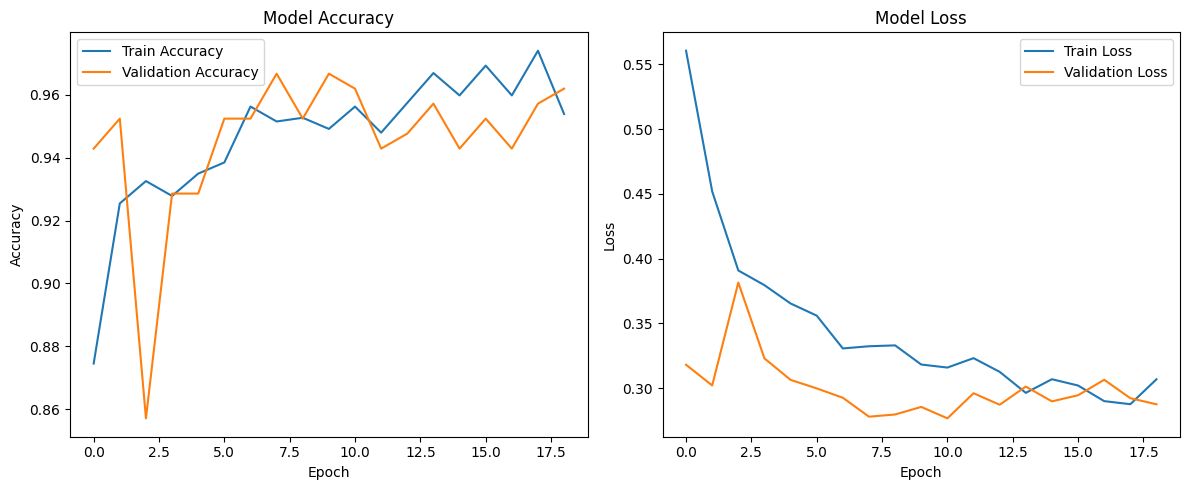

In [24]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
model.save('face_recognition_model.h5')
print("Model saved as 'face_recognition_model.h5'.")

Model saved as 'face_recognition_model.h5'.
